In [7]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report


seq_len = 30*4
overlap = 0.5
stride = int(seq_len * (1 - overlap))
batch_size = 256
id="1214"

stride = int(seq_len * (1 - overlap))
print(f"Window size: {seq_len}, Stride: {stride}")

# データ読み込み関数
def load_session(user="U0101", session="S0100", base_dir="../openpack_subset"):
    def load_atr(sensor):
        path = f"{base_dir}/{user}/atr/{sensor}/{session}.csv"
        df = pd.read_csv(path)
        df["datetime"] = pd.to_datetime(df["unixtime"], unit="ms", utc=True).dt.tz_convert("Asia/Tokyo")
        return df

    df_r = load_atr("atr01")  # 右手
    df_l = load_atr("atr02")  # 左手

    #df_op = pd.read_csv(f"{base_dir}/{user}/annotation/openpack-operations/{session}.csv")
    df_op = pd.read_csv(f"{base_dir}/{user}/annotation/openpack-actions/{session}.csv")
    df_op["start"] = pd.to_datetime(df_op["start"], format="mixed").dt.tz_convert("Asia/Tokyo")
    df_op["end"]   = pd.to_datetime(df_op["end"], format="mixed").dt.tz_convert("Asia/Tokyo")
    return df_r, df_l, df_op


# ウィンドウ分割
def window_split(df_r, df_l, df_op, window_size=256, stride=128):
    # 両手を結合 (12ch)
    df_r = df_r.sort_values("unixtime")
    df_l = df_l.sort_values("unixtime")

    # df = pd.merge_asof(
    #     df_r, df_l,
    #     on="unixtime",
    #     suffixes=("_r", "_l"),
    #     tolerance=20,  # 20ミリ秒以内で近い値をマッチ
    #     direction="nearest"
    # )
    # arr = df[[
    #     "acc_x_r","acc_y_r","acc_z_r","gyro_x_r","gyro_y_r","gyro_z_r",
    #     #"acc_x_l","acc_y_l","acc_z_l","gyro_x_l","gyro_y_l","gyro_z_l" # 左手
    # ]].values
    # unixtime = df["unixtime"].values

    arr = df_l[[
        "acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z",
    ]].values
    unixtime = df_l["unixtime"].values

     # ウィンドウ分割
    windows, labels = [], []
    for start in range(0, len(arr) - window_size, stride):
        end = start + window_size
        win = arr[start:end].T  # (12, 256)
        t_ts = pd.to_datetime(unixtime[start + window_size//2], unit="ms", utc=True).tz_convert("Asia/Tokyo")
        op = df_op[(df_op["start"] <= t_ts) & (t_ts <= df_op["end"])]
        #label = op["operation"].values[0] if len(op) > 0 else "None"
        label = op["action"].values[0] if len(op) > 0 else "None"
        windows.append(win)
        labels.append(label)
    return np.array(windows), np.array(labels)


# Dataset 定義
class IMUDataset(Dataset):
    def __init__(self, X, y):
        X = X.copy()
        # acc: m/s² → g
        # X[:, 0:3, :] /= 9.80665
        # gyro: deg/s → rad/s
        X[:, 3:6, :] *= np.pi / 180.0
        
        self.X = torch.tensor(X, dtype=torch.float32) #.unsqueeze(-1) 
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]



Window size: 120, Stride: 60


In [2]:
# # --- データ読み込みと分割 ---
#train_users = ["U0101", "U0102", "U0103", "U0104", "U0105", "U0106", "U0107", "U0108", "U0109", "U0110",]

# train_users = ["U0101", "U0102", "U0103", "U0104", "U0105",
#         "U0106", "U0107", "U0108", "U0109", "U0110",
#         "U0111", "U0201", "U0206", "U0207", "U0208",
#         "U0209"
#         ]

train_users = [
    "U0101", "U0102", "U0103", "U0104", "U0105",
    "U0106", "U0107", "U0108", "U0109", "U0110",
    "U0111",
    "U0201", "U0202", "U0203", "U0204", "U0205",
    "U0206", "U0207", "U0208", "U0209", "U0210",
]


train_sessions = ["S0200", "S0300", "S0400", "S0500"]
test_sessions = ["S0100"]

X_train, y_train, X_test, y_test = [], [], [], []
total_sec_train = 0.0
total_sec_test = 0.0

# --- 訓練データ ---
for user in train_users:
    for sess in train_sessions:
        if user == "U0104" and sess == "S0500":
            continue  # U0105 の S0500 は欠損
        df_r, df_l, df_op = load_session(user, sess)
        X, y = window_split(df_r, df_l, df_op, window_size=seq_len, stride=stride)
        #valid = y != "None"
        #X_train.append(X[valid])
        #y_train.append(y[valid])
        X_train.append(X)
        y_train.append(y)

# --- テストデータ（全被験者の S0100）---
for user in train_users:
    for sess in test_sessions:
        df_r, df_l, df_op = load_session(user, sess)
        X, y = window_split(df_r, df_l, df_op, window_size=seq_len, stride=stride)
        #valid = y != "None"
        #X_test.append(X[valid])
        #y_test.append(y[valid])
        X_test.append(X)
        y_test.append(y)

# --- 結合 ---
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")



# DataLoader
le = LabelEncoder()
le.fit(np.concatenate([y_train, y_test]))
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)
train_loader = DataLoader(IMUDataset(X_train, y_train_enc), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(IMUDataset(X_test,  y_test_enc),  batch_size=batch_size, shuffle=False)


Train: (79182, 6, 120), Test: (24788, 6, 120)


In [3]:
print(f"Number of classes: {len(le.classes_)}")
print("num_windows : train =", len(y_train), ", test =", len(y_test))
print("duratioon") #calculate duration [hours] from number of windows
print("  train =", len(y_train) * (stride / 30) / 3600.0, "hours")
print("  test  =", len(y_test)  * (stride / 30) / 3600.0, "hours")

Number of classes: 32
num_windows : train = 79182 , test = 24788
duratioon
  train = 43.99 hours
  test  = 13.77111111111111 hours


In [13]:
import numpy as np
from scipy.spatial.transform import Rotation as R
import scipy.interpolate

# def jitter(X, noise_ratio=0.05):
#     std = np.std(X, axis=(1, 2), keepdims=True)
#     noise = np.random.normal(loc=0, scale=noise_ratio * std, size=X.shape)
#     return X + noise

# def scale(X, scale_ratio=0.7):
#     std = np.std(X, axis=(1, 2), keepdims=True)
#     factor = np.random.normal(loc=1.0, scale=scale_ratio * std, size=(X.shape[0], X.shape[1], 1))
#     return X * factor

def jitter(X):
    sigma = np.array([0.1, 0.1, 0.1,   # acc [g]
                      0.1, 0.1, 0.1])[:, None]
    noise = np.random.normal(0, sigma, size=X.shape)
    return X + noise

def scale(X, scale_sigma=0.2):
    factor = np.random.normal(
        loc=1.0,
        scale=scale_sigma,
        size=(X.shape[0], X.shape[1], 1)
    )
    return X * factor


def rotate(X, angle_range=(-30, 30)):
    batch_size = X.shape[0]
    angles = np.random.uniform(angle_range[0], angle_range[1], size=batch_size)  # -30度〜30度のランダム回転
    axes = np.random.uniform(-1, 1, size=(batch_size, 3))
    axes = axes / np.linalg.norm(axes, axis=1, keepdims=True)  # 正規化
    rotations = R.from_rotvec(np.deg2rad(angles)[:, None] * axes)
    rotated_linacc = np.array([rot.apply(sample.T).T for sample, rot in zip(X[:, :3, :], rotations)])
    rotated_gyro = np.array([rot.apply(sample.T).T for sample, rot in zip(X[:, 3:, :], rotations)])
    rotated_X = np.concatenate([rotated_linacc, rotated_gyro], axis=1)  # (batch, 6, seq_len)
    return rotated_X


def shift(X, max_shift=30*2):
    shifts = np.random.randint(0, max_shift + 1, size=(X.shape[0]))
    return np.array([np.roll(sample, shift, axis=1) for sample, shift in zip(X, shifts)])

import numpy as np

# def permutate(X, num_segments=4):
#     batch, channel, seq_len = X.shape
#     segment_length = seq_len // num_segments  
#     X_transformed = np.empty_like(X)
#     # --- 区切り点を等間隔に計算 ---
#     segment_points = np.linspace(0, seq_len, num_segments + 1, dtype=int)
#     segment_points[-1] = seq_len  # 最後を正確に合わせる

#     for b in range(batch):
#         for c in range(channel):
            
#             splitted = [X[b, c, segment_points[i]:segment_points[i+1]] for i in range(len(segment_points) - 1)]
#             np.random.shuffle(splitted)
#             X_transformed[b, c] = np.concatenate(splitted, axis=0)

#     return X_transformed

def get_cubic_spline_interpolation(time_stamps, knot_xs, knot_ys):
    spline = scipy.interpolate.CubicSpline(knot_xs, knot_ys, bc_type="clamped")
    return spline(time_stamps)

# def time_warp(X, sigma=1.0, num_knots=4, num_splines=150):
#     batch_size, num_channels, seq_len = X.shape
#     time_stamps = np.arange(seq_len)

#     knot_xs = np.linspace(0, seq_len - 1, num_knots + 2)

#     spline_ys = np.random.normal(loc=1.0, scale=sigma, size=(num_splines, num_knots + 2))
#     spline_values = np.array([
#         get_cubic_spline_interpolation(time_stamps, knot_xs, ys)
#         for ys in spline_ys
#     ])

#     cumulative_sum = np.cumsum(spline_values, axis=1)
#     distorted_time_stamps_all = cumulative_sum / cumulative_sum[:, -1][:, np.newaxis] * (seq_len - 1)

#     random_indices = np.random.randint(num_splines, size=(batch_size, num_channels))

#     X_transformed = np.empty_like(X)

#     for b in range(batch_size):
#         for c in range(num_channels):
#             warped_time_stamps = distorted_time_stamps_all[random_indices[b, c]]
#             X_transformed[b, c, :] = np.interp(time_stamps, warped_time_stamps, X[b, c, :])

#     return X_transformed

def permutate(X, num_segments=4):
    batch, channel, seq_len = X.shape
    # 区切り点の計算（等間隔でない場合はlinspaceでOK）
    segment_points = np.linspace(0, seq_len, num_segments + 1, dtype=int)
    
    X_transformed = np.empty_like(X)

    for b in range(batch):
        # 【修正点】バッチごとにランダムな順序を一つ決める（全チャンネル共通）
        perm_indices = np.random.permutation(num_segments)
        
        for c in range(channel):
            # 分割
            splitted = [X[b, c, segment_points[i]:segment_points[i+1]] for i in range(num_segments)]
            
            # 【修正点】共通のインデックスで並び替え
            shuffled_segments = [splitted[i] for i in perm_indices]
            
            # 結合
            X_transformed[b, c] = np.concatenate(shuffled_segments, axis=0)

    return X_transformed

def time_warp(X, sigma=1.0, num_knots=4, num_splines=150):
    batch_size, num_channels, seq_len = X.shape
    time_stamps = np.arange(seq_len)

    knot_xs = np.linspace(0, seq_len - 1, num_knots + 2)

    spline_ys = np.random.normal(loc=1.0, scale=sigma, size=(num_splines, num_knots + 2))
    spline_values = np.array([
        get_cubic_spline_interpolation(time_stamps, knot_xs, ys)
        for ys in spline_ys
    ])

    cumulative_sum = np.cumsum(spline_values, axis=1)
    distorted_time_stamps_all = cumulative_sum / cumulative_sum[:, -1][:, np.newaxis] * (seq_len - 1)
    
    # 【修正点】channel次元を持たせず、バッチごとに1つのインデックスを決める
    random_indices = np.random.randint(num_splines, size=(batch_size)) 

    X_transformed = np.empty_like(X)

    for b in range(batch_size):
        # バッチ内の全チャンネルで同じ時間軸を使う
        warped_time_stamps = distorted_time_stamps_all[random_indices[b]]
        
        for c in range(num_channels):
            X_transformed[b, c, :] = np.interp(time_stamps, warped_time_stamps, X[b, c, :])

    return X_transformed

torch.Size([256, 6, 120])


/tmp/ipykernel_2566195/3149470157.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


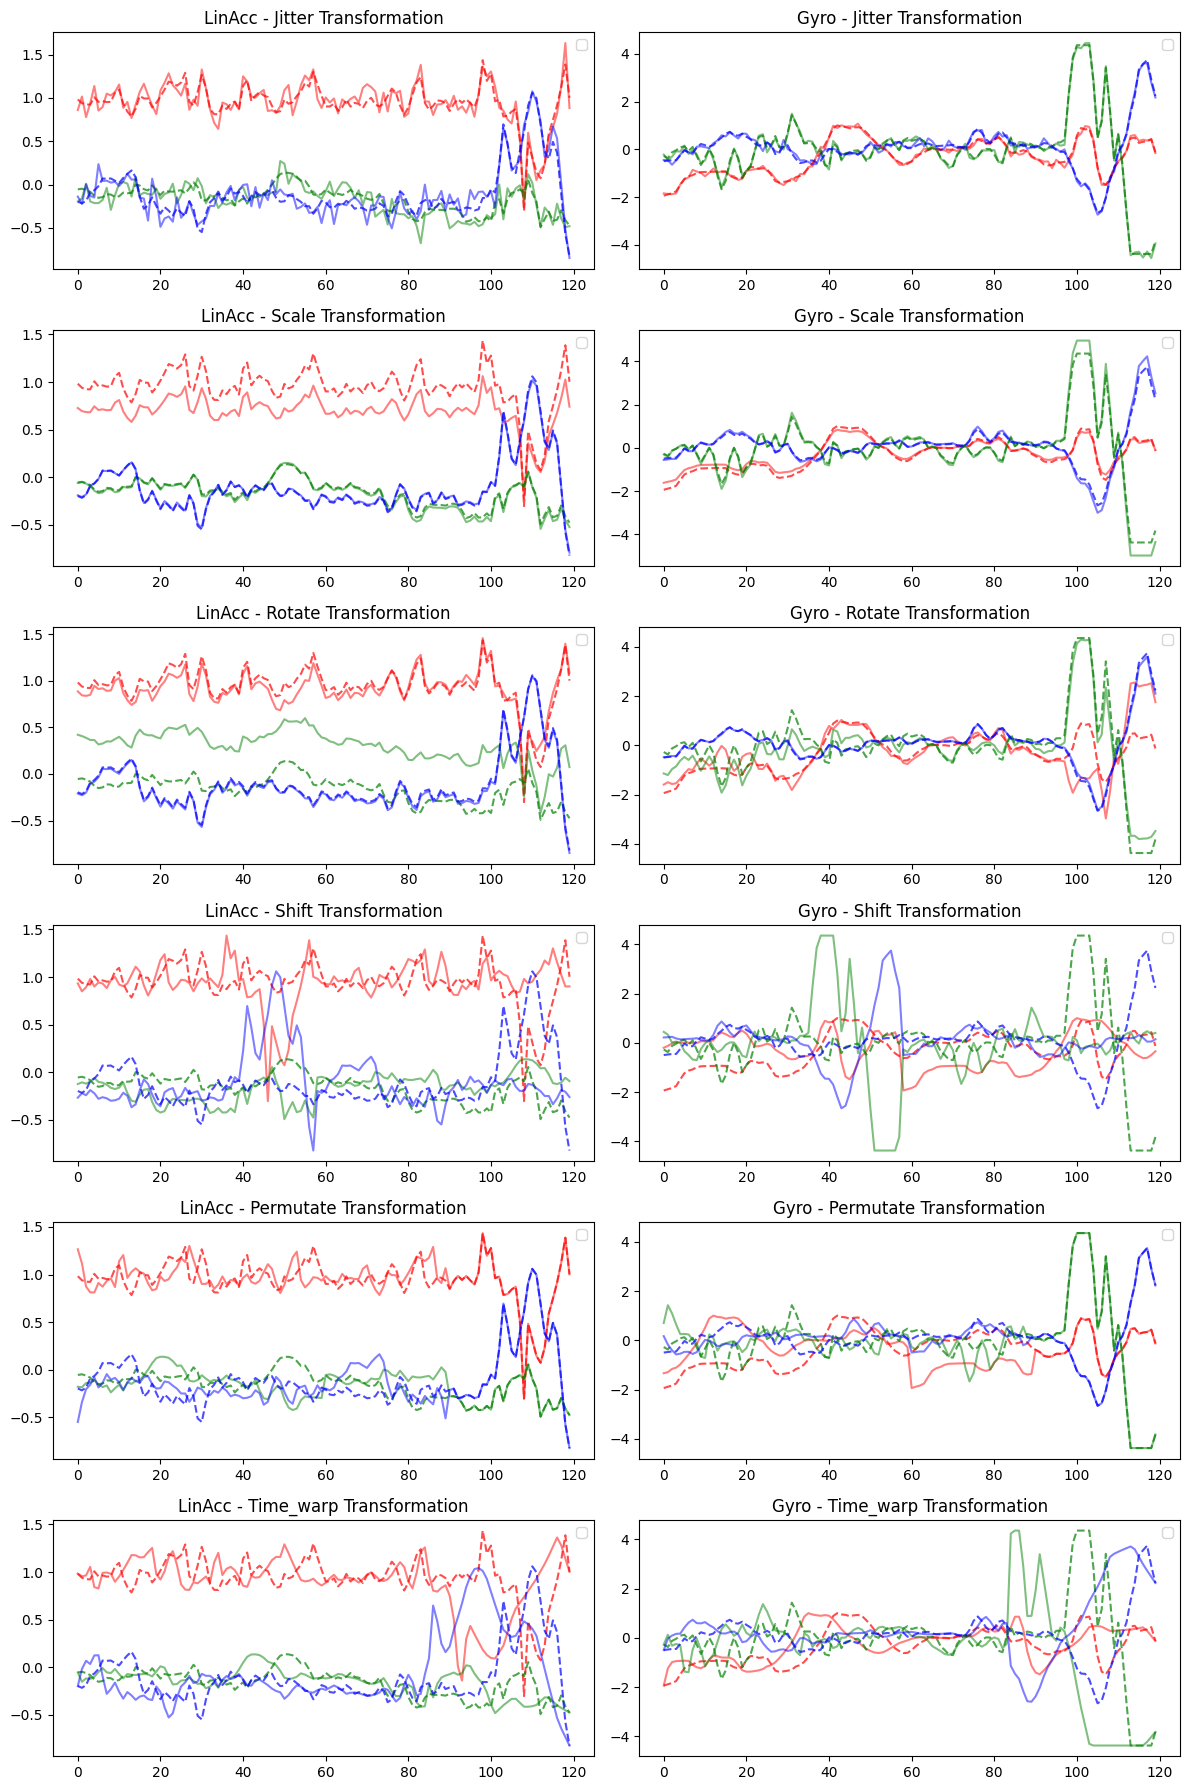

In [14]:
import numpy as np
import matplotlib.pyplot as plt


axis_colors = ['red', 'green', 'blue']


for signals, _ in train_loader:

    #signals = signals.squeeze(-1)
    print(signals.shape)
    signals = signals.numpy()  

    # 変換を適用
    transformed_signals = {
        "Jitter": jitter(signals),
        "Scale": scale(signals),
        "Rotate": rotate(signals),
        "Shift": shift(signals),
        "Permutate": permutate(signals),
        "Time_warp": time_warp(signals)
    }

    # 変換前のデータ
    original_signal = signals[0]  # (6, seq_len)

    # 変換後のデータ（
    transformed_signals = {name: data[0] for name, data in transformed_signals.items()}  # (6, seq_len)

    # プロット
    fig, axes = plt.subplots(len(transformed_signals), 2, figsize=(12, 3 * len(transformed_signals)))

    for i, (name, transformed_signal) in enumerate(transformed_signals.items()):
        for k in range(2):  # k=0: LinAcc (左), k=1: Gyro (右)
            ax = axes[i, k]

            for j, color in enumerate(axis_colors):
                idx = j if k == 0 else j + 3  # LinAcc (0-2), Gyro (3-5)

                # Before (破線, 濃い色)
                ax.plot(original_signal[idx][:], 
                        linestyle='dashed', alpha=0.7, color=color)
                
                # After (実線, 薄い色)
                ax.plot(transformed_signal[idx][:],
                        linestyle='solid', alpha=0.5, color=color)
                

            ax.set_title(f"{['LinAcc', 'Gyro'][k]} - {name} Transformation")
            ax.legend()

    plt.tight_layout()
    plt.show()
    
    break 

In [21]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import random

# class CNN_Encoder(nn.Module):
#     def __init__(self, input_dim, seq_len, hidden_dim, feature_dim, dropout=0.3):
#         super(CNN_Encoder, self).__init__()

#         # Conv1: 256 -> 64
#         self.conv1 = nn.Conv1d(input_dim, hidden_dim, kernel_size=10, stride=4, padding=3)
#         self.bn1 = nn.BatchNorm1d(hidden_dim)

#         # Conv2: 64 -> 32
#         self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=6, stride=2, padding=2)
#         self.bn2 = nn.BatchNorm1d(hidden_dim)

#         # Conv3: 32 -> 16
#         self.conv3 = nn.Conv1d(hidden_dim, feature_dim, kernel_size=4, stride=2, padding=1)
#         self.bn3 = nn.BatchNorm1d(feature_dim)

#         # Dropout
#         self.dropout = nn.Dropout(dropout)

#     def forward(self, x):
#         x = x.squeeze(-1)
#         x = F.relu(self.bn1(self.conv1(x)))  # Conv1
#         x = F.relu(self.bn2(self.conv2(x)))  # Conv2
#         x = F.relu(self.bn3(self.conv3(x)))  # Conv3

#         x = self.dropout(x)

#         # Global Mean Pooling
#         x = torch.mean(x, dim=-1)  # (batch, feature_dim)

#         return x
    
# class CNNShortWindow(nn.Module):
#     def __init__(self, input_dim=6, hidden_dim=64, feature_dim=128):
#         super().__init__()
#         ks = 5
#         nf = hidden_dim
#         self.conv = nn.Sequential(
#             nn.Conv2d(input_dim, hidden_dim, kernel_size=(ks,1), padding=(ks//2,0)),
#             nn.BatchNorm2d(hidden_dim),
#             nn.ReLU(),
#             nn.Conv2d(hidden_dim, hidden_dim, kernel_size=(ks,1), padding=(ks//2,0)),
#             nn.BatchNorm2d(hidden_dim),
#             nn.ReLU(),
#             nn.Conv2d(hidden_dim, feature_dim, kernel_size=(ks,1), padding=(ks//2,0)),
#             nn.BatchNorm2d(feature_dim),
#             nn.ReLU(),
#         )
#         self.pool = nn.AdaptiveAvgPool2d((1,1))
#         #self.fc = nn.Linear(nf, num_classes)

#     def forward(self, x):
#         x = self.conv(x)
#         x = self.pool(x).squeeze(-1).squeeze(-1)
#         #print(x.shape)
#         return x
    

# class SimCLR(nn.Module):
#     def __init__(self, input_dim, seq_len, hidden_dim, feature_dim, projection_dim, dropout=0.3):
#         super(SimCLR, self).__init__()

#         # CNN Encoder 
#         self.encoder = CNN_Encoder(input_dim, seq_len, hidden_dim, feature_dim, dropout)
#         #self.encoder = CNNShortWindow(input_dim, hidden_dim, feature_dim)

#         # Projection Head
#         self.projection = nn.Sequential(
#             nn.Linear(feature_dim, feature_dim),
#             nn.ReLU(),
#             nn.Linear(feature_dim, projection_dim)
#         )

#     def forward(self, x):
#         # CNNで特徴抽出
#         feature_embedding = self.encoder(x)  # (batch_size, feature_dim)
#         # プロジェクション層
#         projection = self.projection(feature_embedding)  # (batch_size, projection_dim)
#         # L2正規化
#         projection = F.normalize(projection, dim=-1)

#         return projection

from models import SimCLR, CNN_Encoder

In [22]:
import torch
import torch.nn.functional as F

def NT_XentLoss(z_i, z_j, temperature=0.2):
    """Normalized Temperature-scaled Cross-Entropy Loss (NT-Xent)"""
    batch_size = z_i.shape[0]

    # 特徴ベクトルの L2 正規化
    z_i = F.normalize(z_i, dim=1)  # (batch, feature_dim)
    z_j = F.normalize(z_j, dim=1)  # (batch, feature_dim)

    # 2N x 2N の類似度行列を作成
    z = torch.cat([z_i, z_j], dim=0)  # (2*batch, feature_dim)
    similarity_matrix = torch.matmul(z, z.T)  # (2*batch, 2*batch)

    # 温度スケーリング
    similarity_matrix /= temperature

    # 自分自身の類似度を除外するためのマスク
    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
    similarity_matrix = similarity_matrix.masked_fill(mask, -float("inf"))

    # ソフトマックス適用
    sim_exp = torch.exp(similarity_matrix)
    sim_sum = sim_exp.sum(dim=1, keepdim=True)
    sim_probs = sim_exp / sim_sum  # ソフトマックス後の確率

    # 正例ペアのインデックス (偶数行は i+batch, 奇数行は i-batch)
    labels = torch.arange(batch_size, device=z.device)
    labels = torch.cat([labels + batch_size, labels])  # (2*batch,)

    # -log を適用
    loss = -torch.log(sim_probs[torch.arange(2 * batch_size), labels]).mean()

    # Accuracy 計算
    preds = similarity_matrix.argmax(dim=1)  # (2*batch,)
    acc = (preds == labels).float().mean().item()

    return loss, acc

In [73]:
import numpy as np

def augment(X, prob=0.5):
    #X = X.squeeze(-1)
    #X = X.numpy()
    #X_origin = X.copy()
    
    if np.random.rand() < 1.0:  
        X = jitter(X)
    if np.random.rand() < 0.5:
        X = scale(X)
    if np.random.rand() < 0.5:
        X = rotate(X)
    if np.random.rand() < 0.5:
        X = shift(X)
    if np.random.rand() < 0.2: 
        X = permutate(X)
    if np.random.rand() < 0.2: 
        X = time_warp(X)

    X = torch.tensor(X, dtype=torch.float32)
    #X = X.unsqueeze(-1)
    return X

torch.Size([256, 6, 120])


/tmp/ipykernel_1898264/1371143888.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return X + noise
/tmp/ipykernel_1898264/1371143888.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return X * factor
/tmp/ipykernel_1898264/609433219.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32)


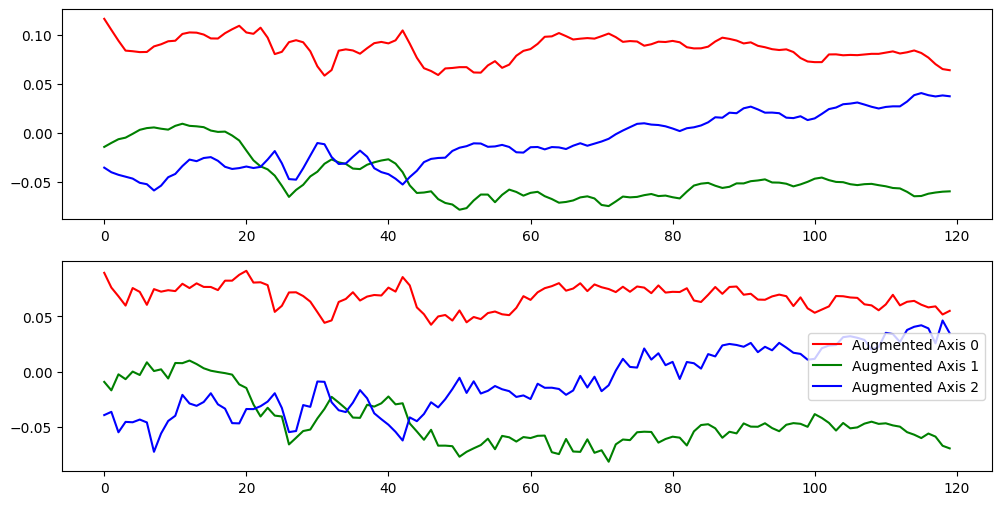

In [91]:
#test augment function
for signals, _ in train_loader:
    #signals = signals.numpy()  
    augmented_signals = augment(signals)
    print(augmented_signals.shape)
    figure, ax = plt.subplots(2,1, figsize=(12,6))
    for axis, color in zip(range(3), axis_colors):
        ax[0].plot(signals[0,axis,:], color=color, label=f"Original Axis {axis}")
        ax[1].plot(augmented_signals[0,axis,:], color=color, label=f"Augmented Axis {axis}")
   
    plt.legend()
    plt.show()
    break

In [24]:
--

SyntaxError: invalid syntax (3659366440.py, line 1)

In [25]:
from models import SimCLR, CNN_Encoder
import torch
import torch.optim as optim

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# モデル構築（あなたのパラメータをそのまま採用）
model = SimCLR(
    input_dim=6,
    seq_len=seq_len,
    hidden_dim=64,
    feature_dim=128,
    projection_dim=64,
    dropout=0.3
).to(device)

user_test = "all_S100v3"
num_epochs = 100
save_interval = 20

optimizer = optim.Adam(model.parameters(), lr=1e-3)
#writer = SummaryWriter(f"runs/SimCLR_LOSO_{user_test}")

fname = f"./model/encoder_leave_{user_test}_0.pth"
torch.save(model.state_dict(), fname)
print(f"Saved {fname}")

# === training ===
train_loss_list, test_loss_list = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss, train_acc = 0, 0
    n = 0

    for signals, _ in train_loader:
        n += 1
        optimizer.zero_grad()

        s1 = augment(signals).to(device)
        s2 = augment(signals).to(device)

        z1 = model(s1)
        z2 = model(s2)

        loss, acc = NT_XentLoss(z1, z2, temperature=0.2)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += acc

    train_loss /= n
    train_acc /= n

    # ---- test ----
    model.eval()
    test_loss, test_acc = 0, 0
    m = 0

    with torch.no_grad():
        for signals, _ in test_loader:
            m += 1
            s1 = augment(signals).to(device)
            s2 = augment(signals).to(device)
            z1 = model(s1)
            z2 = model(s2)
            loss, acc = NT_XentLoss(z1, z2, temperature=0.2)

            test_loss += loss.item()
            test_acc += acc

    test_loss /= m
    test_acc /= m

    #writer.add_scalars("Loss", {"Train": train_loss, "Test": test_loss}, epoch+1)
    #writer.add_scalars("Acc",  {"Train": train_acc,  "Test": test_acc},  epoch+1)

    print(f"[{user_test}] Epoch {epoch+1:03d} | "
            f"Train Loss {train_loss:.4f}, Test Loss {test_loss:.4f}, Train Acc {train_acc:.4f}, Test Acc {test_acc:.4f}")

    # 保存
    if (epoch + 1) % save_interval == 0:
        fname = f"./model/encoder_leave_{user_test}_{epoch+1}.pth"
        torch.save(model.state_dict(), fname)
        print(f"Saved {fname}")

#writer.close()

# 最終モデル保存
final_path = f"./model/encoder_leave_{user_test}.pth"
torch.save(model.state_dict(), final_path)
print(f"[DONE] Saved {final_path}")

Saved ./model/encoder_leave_all_S100v3_0.pth
[all_S100v3] Epoch 001 | Train Loss 4.0769, Test Loss 3.9611, Train Acc 0.3311, Test Acc 0.3753
[all_S100v3] Epoch 002 | Train Loss 3.6061, Test Loss 3.6994, Train Acc 0.4768, Test Acc 0.4706
[all_S100v3] Epoch 003 | Train Loss 3.4912, Test Loss 3.7531, Train Acc 0.5168, Test Acc 0.4495
[all_S100v3] Epoch 004 | Train Loss 3.4036, Test Loss 3.5883, Train Acc 0.5424, Test Acc 0.5153
[all_S100v3] Epoch 005 | Train Loss 3.3874, Test Loss 3.4500, Train Acc 0.5452, Test Acc 0.5686
[all_S100v3] Epoch 006 | Train Loss 3.2904, Test Loss 3.4993, Train Acc 0.5786, Test Acc 0.5388
[all_S100v3] Epoch 007 | Train Loss 3.2754, Test Loss 3.4913, Train Acc 0.5824, Test Acc 0.5444
[all_S100v3] Epoch 008 | Train Loss 3.2499, Test Loss 3.4513, Train Acc 0.5927, Test Acc 0.5491
[all_S100v3] Epoch 009 | Train Loss 3.2575, Test Loss 3.4129, Train Acc 0.5830, Test Acc 0.5656
[all_S100v3] Epoch 010 | Train Loss 3.2369, Test Loss 3.4972, Train Acc 0.5914, Test Acc 0.

In [ ]:
import numpy as np
import pandas as pd

seq_len, stride = 120, 60  # 2秒strideでwindow化

records = []

for u in [
    "U0101", "U0102", "U0103", "U0104", "U0105",
    "U0106", "U0107", "U0108", "U0109", "U0110",
    "U0111", "U0201", "U0206", "U0207", "U0208",
    "U0209"
]:

    for s in ["S0100","S0200","S0300","S0400","S0500"]:
        print("Processing user:", u, "session:", s)
        if u == "U0104" and s == "S0500":  # known broken skip
            continue
        try:
            df_r, df_l, df_op = load_session(u, s)
        except:
            continue
        X, y = window_split(df_r, df_l, df_op, window_size=seq_len, stride=stride)
        for xb, yb in zip(X, y):
            #if yb == "None":  # 無効windowは入れない
            #    continue
            records.append({
                "user": u,
                "X": xb,      # shape (120,6) 想定
                "y": yb,      # str label
            })

df_save = pd.DataFrame(records)
# Xはobject columnに配列が入るので np.savez 用にlistで保持
X_all = np.stack([r["X"] for r in records])
y_all = np.array([r["y"] for r in records])
u_all = np.array([r["user"] for r in records for _ in ["dummy"]][:len(X_all)])

print("Saving windowed dataset:", X_all.shape, y_all.shape, u_all.shape)

np.savez("openpack_windowed.npz", X=X_all, y=y_all, user=u_all)
print("Saved: openpack_windowed.npz")


Processing user: U0101 session: S0100
Processing user: U0101 session: S0200
Processing user: U0101 session: S0300
Processing user: U0101 session: S0400
Processing user: U0101 session: S0500
Processing user: U0102 session: S0100
Processing user: U0102 session: S0200
Processing user: U0102 session: S0300
Processing user: U0102 session: S0400
Processing user: U0102 session: S0500
Processing user: U0103 session: S0100
Processing user: U0103 session: S0200
Processing user: U0103 session: S0300
Processing user: U0103 session: S0400
Processing user: U0103 session: S0500
Processing user: U0104 session: S0100
Processing user: U0104 session: S0200
Processing user: U0104 session: S0300
Processing user: U0104 session: S0400
Processing user: U0104 session: S0500
Processing user: U0105 session: S0100
Processing user: U0105 session: S0200
Processing user: U0105 session: S0300
Processing user: U0105 session: S0400
Processing user: U0105 session: S0500
Processing user: U0106 session: S0100
Processing u

In [ ]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

# def load_user_data(user_test, seq_len, stride):
#     """
#     user_test: テストにする代表 subject ID (e.g., "U0105")
#     returns: X_train, y_train, X_test, y_test
#     """
#     import numpy as np

#     # 同一人物リンク（代表IDへ）
#     same_person = {
#         "U0202": "U0105",
#         "U0203": "U0108",
#         "U0204": "U0110",
#         "U0205": "U0107",
#         "U0210": "U0103",
#     }

#     # raw 21 ID
#     all_raw_users = [
#         "U0101","U0102","U0103","U0104","U0105","U0106","U0107",
#         "U0108","U0109","U0110","U0111","U0201","U0202","U0203",
#         "U0204","U0205","U0206","U0207","U0208","U0209","U0210",
#     ]

#     sessions = ["S0100","S0200","S0300","S0400","S0500"]

#     X_train, y_train, X_test, y_test = [], [], [], []

#     for user in all_raw_users:
#         for sess in sessions:

#             # known broken bag skip
#             if user == "U0104" and sess == "S0500":
#                 continue

#             df_r, df_l, df_op = load_session(user, sess)
#             X, y = window_split(df_r, df_l, df_op,
#                                 window_size=seq_len, stride=stride)
#             mask = (y != "None")
#             person = same_person.get(user, user)

#             # 対象人物と同一人物のペアだけ test 用に追加
#             if person == user_test:
#                 print(f"[{user_test}] {user} {sess} -> Test")
#                 X_test.append(X[mask])
#                 y_test.append(y[mask])
#             else:
#                 print(f"[{user_test}] {user} {sess} -> Train")
#                 X_train.append(X[mask])
#                 y_train.append(y[mask])

#     X_train = np.concatenate(X_train)
#     y_train = np.concatenate(y_train)
#     X_test = np.concatenate(X_test)
#     y_test = np.concatenate(y_test)

#     print(f"[Split] subject={user_test}, train={X_train.shape}, test={X_test.shape}")
#     return X_train, y_train, X_test, y_test

def load_user_data(user_test, seq_len=120, stride=60):
    import numpy as np

    data = np.load("openpack_windowed.npz", allow_pickle=True)
    X, y, user = data["X"], data["y"], data["user"]

    assert len(X) == len(y) == len(user)

    X_train, y_train, X_test, y_test = [], [], [], []
    seen_test = 0

    for xi, yi, ui in zip(X, y, user):
        if ui == user_test:
            if seen_test == 0:
                print(f"[INFO] {ui} first window → Test")
            X_test.append(xi)
            y_test.append(yi)
            seen_test += 1
        else:
            X_train.append(xi)
            y_train.append(yi)

    X_train = np.stack(X_train) if X_train else None
    X_test  = np.stack(X_test)  if X_test else None

    print(f"[Split] Test subject={user_test}, "
          f"train={X_train.shape if X_train is not None else 0}, "
          f"test={X_test.shape if X_test is not None else 0}")

    return X_train, np.array(y_train), X_test, np.array(y_test)



def build_loaders(X_train, y_train, X_test, y_test, batch_size):
    le = LabelEncoder()
    le.fit(np.concatenate([y_train, y_test]))
    y_train_enc = le.transform(y_train)
    y_test_enc = le.transform(y_test)

    train_loader = DataLoader(
        IMUDataset(X_train, y_train_enc),
        batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        IMUDataset(X_test, y_test_enc),
        batch_size=batch_size, shuffle=False
    )
    return train_loader, test_loader, le

def train_simclr(train_loader, test_loader, user_test,
                 seq_len, id="1204", num_epochs=100, save_interval=20):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # モデル構築（あなたのパラメータをそのまま採用）
    model = SimCLR(
        input_dim=6,
        seq_len=seq_len,
        hidden_dim=64,
        feature_dim=128,
        projection_dim=64,
        dropout=0.3
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    #writer = SummaryWriter(f"runs/SimCLR_LOSO_{user_test}")

    fname = f"./model/encoder_leave_{user_test}_0.pth"
    torch.save(model.state_dict(), fname)
    print(f"Saved {fname}")

    # === training ===
    train_loss_list, test_loss_list = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_acc = 0, 0
        n = 0

        for signals, _ in train_loader:
            n += 1
            optimizer.zero_grad()

            s1 = augment(signals).to(device)
            s2 = augment(signals).to(device)

            z1 = model(s1)
            z2 = model(s2)

            loss, acc = NT_XentLoss(z1, z2, temperature=0.2)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += acc

        train_loss /= n
        train_acc /= n

        # ---- test ----
        model.eval()
        test_loss, test_acc = 0, 0
        m = 0

        with torch.no_grad():
            for signals, _ in test_loader:
                m += 1
                s1 = augment(signals).to(device)
                s2 = augment(signals).to(device)
                z1 = model(s1)
                z2 = model(s2)
                loss, acc = NT_XentLoss(z1, z2, temperature=0.2)

                test_loss += loss.item()
                test_acc += acc

        test_loss /= m
        test_acc /= m

        #writer.add_scalars("Loss", {"Train": train_loss, "Test": test_loss}, epoch+1)
        #writer.add_scalars("Acc",  {"Train": train_acc,  "Test": test_acc},  epoch+1)

        print(f"[{user_test}] Epoch {epoch+1:03d} | "
              f"Train Loss {train_loss:.4f}, Test Loss {test_loss:.4f}, Train Acc {train_acc:.4f}, Test Acc {test_acc:.4f}")

        # 保存
        if (epoch + 1) % save_interval == 0:
            fname = f"./model/encoder_leave_{user_test}_{epoch+1}.pth"
            torch.save(model.state_dict(), fname)
            print(f"Saved {fname}")

    #writer.close()

    # 最終モデル保存
    final_path = f"./model/encoder_leave_{user_test}.pth"
    torch.save(model.state_dict(), final_path)
    print(f"[DONE] Saved {final_path}")


In [ ]:
--

In [ ]:
train_simclr(
        train_loader, test_loader,
        user_test="allS100",
        seq_len=seq_len,
        id="1204", num_epochs=100, save_interval=20
    )

In [ ]:
--

SyntaxError: invalid syntax (3659366440.py, line 1)

In [ ]:
all_test_users = ["U0101", "U0102", "U0103", "U0104", "U0105",
             "U0106", "U0107", "U0108", "U0109", "U0110",
             "U0111", "U0201", "U0206", "U0207", "U0208",
             "U0209"]


seq_len = 30*4
stride = int(seq_len * (1 - 0.5))  # 50% overlap
batch_size = 256

for user_test in all_test_users[5:]:
    print(f"\n===== LOSO Pretraining for {user_test} =====")

    X_train, y_train, X_test, y_test = load_user_data(
        user_test, seq_len, stride
    )

    train_loader, test_loader,le = build_loaders(
        X_train, y_train, X_test, y_test, batch_size
    )

    print(X_train.shape,X_test.shape)



    #print(le.classes_)

    train_simclr(
        train_loader, test_loader,
        user_test=user_test,
        seq_len=seq_len,
        id="1204", num_epochs=100, save_interval=20
    )



===== LOSO Pretraining for U0106 =====
[INFO] U0106 first window → Test
[Split] Test subject=U0106, train=(74927, 6, 120), test=(5208, 6, 120)
(74927, 6, 120) (5208, 6, 120)
Saved ./model/encoder_leave_U0106_0.pth
[U0106] Epoch 001 | Train Loss 4.1739, Test Loss 3.8354, Train Acc 0.2856, Test Acc 0.3868
[U0106] Epoch 002 | Train Loss 3.6831, Test Loss 3.8918, Train Acc 0.4121, Test Acc 0.3404
[U0106] Epoch 003 | Train Loss 3.5859, Test Loss 3.7503, Train Acc 0.4460, Test Acc 0.4113
[U0106] Epoch 004 | Train Loss 3.4376, Test Loss 3.3791, Train Acc 0.4904, Test Acc 0.5625
[U0106] Epoch 005 | Train Loss 3.3856, Test Loss 3.4857, Train Acc 0.5039, Test Acc 0.4841
[U0106] Epoch 006 | Train Loss 3.3601, Test Loss 3.8042, Train Acc 0.5171, Test Acc 0.3623
[U0106] Epoch 007 | Train Loss 3.2836, Test Loss 3.4413, Train Acc 0.5457, Test Acc 0.4844
[U0106] Epoch 008 | Train Loss 3.3515, Test Loss 3.4893, Train Acc 0.5138, Test Acc 0.4746
[U0106] Epoch 009 | Train Loss 3.2145, Test Loss 3.5462, 

In [ ]:
import numpy as np
from collections import defaultdict

def analyze_openpack_npz(npz_path="openpack_windowed.npz"):
    """
    # 関数の機能: OpenPack window化済みデータの統計情報を表示
    print:
        - shape
        - distinct users count
        - label distribution
    """
    data = np.load(npz_path, allow_pickle=True)
    X = data["X"]
    y = data["y"]
    user = data["user"]

    print("=== Dataset Overview ===")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("user shape:", user.shape)

    print("\n=== Subject Count ===")
    print("Unique raw user IDs:", np.unique(user))
    print("Number of unique subjects:", len(np.unique(user)))

    print("\n=== Label Distribution (top 10 example) ===")
    label_count = defaultdict(int)
    for label in y:
        label_count[label] += 1
    for label, count in sorted(label_count.items(), key=lambda x: -x[1])[:10]:
        print(f"{label}: {count}")

    print("\n=== All Labels ===")
    print("Unique labels:", np.unique(y))

# 1回だけ実行
analyze_openpack_npz()


=== Dataset Overview ===
X shape: (80135, 6, 120)
y shape: (80135,)
user shape: (80135,)

=== Subject Count ===
Unique raw user IDs: ['U0101' 'U0102' 'U0103' 'U0104' 'U0105' 'U0106' 'U0107' 'U0108' 'U0109'
 'U0110' 'U0111' 'U0201' 'U0206' 'U0207' 'U0208' 'U0209']
Number of unique subjects: 16

=== Label Distribution (top 10 example) ===
None: 29066
Attach Tape: 9693
Attach Shipping Label: 4016
Write Sign: 3453
Walk to Work Bench: 3285
Attach Box Label: 3214
Write Check Mark: 3171
Bend Flap: 3109
Insert Item into Box: 3105
Pick Cardboard: 1954

=== All Labels ===
Unique labels: ['Attach Box Label' 'Attach Shipping Label' 'Attach Tape' 'Bend Flap'
 'Ignore' 'Insert Item into Box' 'None' 'Others' 'Pick Cardboard'
 'Pick Up Assembled Box' 'Pick Up Box Sheet' 'Pick Up HT'
 'Pick Up Item from Box' 'Pick Up Packed Box' 'Pick Up Pen'
 'Pick Up Sheet' 'Pick Up Shipping Label' 'Push Order Sheet into Tray'
 'Put Item Small Bag' 'Put Packed Box' 'Remove Item Label' 'Scan Box'
 'Scan Item' 'Scan Or

In [ ]:
all_users = ["U0101", "U0102", "U0103", "U0104", "U0105",
             "U0106", "U0107", "U0108", "U0109", "U0110"]

seq_len = 30*4
stride = int(seq_len * (1 - 0.5))  # 50% overlap
batch_size = 256

for user_test in all_users[:]:
    print(f"\n===== LOSO Pretraining for {user_test} =====")

    X_train, y_train, X_test, y_test = load_user_data(
        user_test, seq_len, stride
    )

    train_loader, test_loader,le = build_loaders(
        X_train, y_train, X_test, y_test, batch_size
    )

    #print(le.classes_)

    # train_simclr(
    #     train_loader, test_loader,
    #     user_test=user_test,
    #     seq_len=seq_len,
    #     id="1204", num_epochs=100, save_interval=25
    # )


In [ ]:
--

# Embeddings

In [ ]:
subclass_map = {
    # 0. Pick
    "Pick Cardboard": 0,
    "Pick Up HT": 0,
    "Pick Up Item from Box": 0,
    "Pick Up Packed Box": 0,
    "Pick Up Pen": 0,
    "Pick Up Sheet": 0,
    "Pick Up Shipping Label": 0,

    # 1. Insert
    "Insert Item into Box": 1,

    # 2. Put
    "Put Packed Box": 2,

    # 3. Push
    "Push Order Sheet into Tray": 3,

    # 4. Attach
    "Attach Box Label": 4,
    "Attach Shipping Label": 4,
    "Attach Tape": 4,

    # 5. Scan
    "Scan Box": 5,
    "Scan Item": 5,
    "Scan Order Sheet": 5,
    "Scan Printer": 5,

    # 6. Write
    "Write Check Mark": 6,
    "Write Sign": 6,

    # 7. Box Manipulation (Bend/Turn)
    "Bend Flap": 7,
    "Turn Over Box": 7,

    # 8. Box Manipulation (Separate/Remove)
    "Separate Air Cushion": 8,
    "Remove Item Label": 8,

    # 9. Walk
    "Walk to Work Bench": 9,

    # 10. None
    "None": 10,

    # 11. Exception
    "Ignore": 11,
    "Others": 11,
    "Unknown": 11,
}

# 表示名
subclass_names = {
    0: "Pick",
    1: "Insert",
    2: "Put",
    3: "Push",
    4: "Attach",
    5: "Scan",
    6: "Write",
    7: "Bend/Turn",
    8: "Separate/Remove",
    9: "Walk",
    10: "None",
    11: "Exception"
}



def plot_subclass_embedding(emb_2d, yy_test, save_path):
    yy_sub = np.array([subclass_map[name] for name in yy_test])
    unique_s = np.unique(yy_sub)

    plt.figure(figsize=(12, 10))
    cmap = plt.get_cmap("tab20")

    ordered_s = [10, 11] + [s for s in range(12) if s not in [10, 11]]

    for s in ordered_s:
        idx = (yy_sub == s)

        if s == 10:          # None
            color = (0.7, 0.7, 0.7)
            alpha = 0.30
        elif s == 11:       # Exception
            color = (0.690, 0.85, 0.811)
            alpha = 0.85
        else:
            color = cmap(s % 20)
            alpha = 1.0

        plt.scatter(
            emb_2d[idx, 0], emb_2d[idx, 1],
            s=35, color=color, alpha=alpha,
            label=subclass_names[s]
        )

    plt.xticks([])
    plt.yticks([])
    plt.xlabel("Dimension 1", fontsize=20)
    plt.ylabel("Dimension 2", fontsize=20)

    handles, labels = plt.gca().get_legend_handles_labels()
    desired_order = list(range(12))

    new_handles, new_labels = [], []
    for s in desired_order:
        name = subclass_names[s]
        if name in labels:
            i = labels.index(name)
            new_handles.append(handles[i])
            new_labels.append(labels[i])

    plt.legend(
        new_handles, new_labels,
        fontsize=18, markerscale=2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=6, frameon=False,
        columnspacing=0.6,   # ← 列間の余白（小さくすると詰まる）
        handletextpad=0.4,   # ← マーカーと文字の間の余白
    )

    #plt.title(f"Subclass Embeddings ({save_path})", fontsize=22)

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=200)
    plt.close()


In [ ]:
import glob
from sklearn.manifold import TSNE

def analyse_embedding_subclass(model_dir, test_loader, le, user_test):
    """
    model_dir: 保存済みモデルフォルダ
    test_loader: LOSOで準備した DataLoader（U0101 の Test Data）
    le: LabelEncoder（build_loaders から受け取る）
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_paths = sorted(glob.glob(f"{model_dir}/encoder_leave_{user_test}_*.pth"))
    print("Found models:")
    for p in model_paths:
        print("  ", p)

    # test_loader から y_test を復元する
    # （Dataset の元ラベルは整数 → 必ず y_test_enc）
    all_labels = []
    for _, labels in test_loader:
        all_labels.append(labels.numpy())
    y_test_enc = np.concatenate(all_labels)
    y_test = le.inverse_transform(y_test_enc)

    # ---- 各 epoch のモデルについて埋め込み可視化 ----
    for path in model_paths:
        epoch = path.split("_")[-1].replace(".pth", "")
        print(f"\n[Analyse] Epoch {epoch}: {path}")

        # モデル構築
        model = SimCLR(
            input_dim=6,
            seq_len=seq_len,
            hidden_dim=64,
            feature_dim=128,
            projection_dim=64,
            dropout=0.3
        ).to(device)
        model.load_state_dict(torch.load(path))
        model.eval()

        # ---- 埋め込み抽出 ----
        Z = []
        with torch.no_grad():
            for signals, _ in test_loader:
                signals = signals.to(device)
                z = model(signals)
                Z.append(z.cpu().numpy())
        Z = np.concatenate(Z)

        # ---- TSNE ----
        tsne = TSNE(n_components=2, perplexity=30, random_state=0)
        Z2 = tsne.fit_transform(Z)

        # ---- 色付け & 保存 ----
        save_path = f"runs/embedding_{user_test}/epoch_{epoch}.png"
        plot_subclass_embedding(Z2, y_test, save_path)
        print(f"Saved: {save_path}")


In [ ]:
all_users = ["U0101", "U0102", "U0103", "U0104", "U0105",
             "U0106", "U0107", "U0108", "U0109", "U0110",
             "U0111", "U0201", "U0206", "U0207", "U0208",
             "U0209"]

for user_test in all_users[0:1]:   # U0101 だけ
    print(f"\n===== LOSO Pretraining for {user_test} =====")

    X_train, y_train, X_test, y_test = load_user_data(
        user_test, seq_len, stride
    )

    train_loader, test_loader, le = build_loaders(
        X_train, y_train, X_test, y_test, batch_size
    )

    # ---- 訓練せず保存済みモデルの埋め込み可視化だけ実行 ----
    analyse_embedding_subclass(
        model_dir="./model",
        test_loader=test_loader,
        le=le,
        user_test=user_test
    )



===== LOSO Pretraining for U0101 =====
[INFO] U0101 first window → Test
[Split] Test subject=U0101, train=(75534, 6, 120), test=(4601, 6, 120)
Found models:
   ./model/encoder_leave_U0101_0.pth
   ./model/encoder_leave_U0101_100.pth
   ./model/encoder_leave_U0101_20.pth
   ./model/encoder_leave_U0101_40.pth
   ./model/encoder_leave_U0101_60.pth
   ./model/encoder_leave_U0101_80.pth

[Analyse] Epoch 0: ./model/encoder_leave_U0101_0.pth
Saved: runs/embedding_U0101/epoch_0.png

[Analyse] Epoch 100: ./model/encoder_leave_U0101_100.pth
Saved: runs/embedding_U0101/epoch_100.png

[Analyse] Epoch 20: ./model/encoder_leave_U0101_20.pth
Saved: runs/embedding_U0101/epoch_20.png

[Analyse] Epoch 40: ./model/encoder_leave_U0101_40.pth
Saved: runs/embedding_U0101/epoch_40.png

[Analyse] Epoch 60: ./model/encoder_leave_U0101_60.pth
Saved: runs/embedding_U0101/epoch_60.png

[Analyse] Epoch 80: ./model/encoder_leave_U0101_80.pth
Saved: runs/embedding_U0101/epoch_80.png


In [ ]:
from PIL import Image
import glob

def make_gif(input_dir="runs/embedding_U0101", output_path="embedding_U0101.gif", duration=500):
    """
    duration: 各フレームの表示時間(ms) 
              → 500ms = 0.5秒/画像
    """
    # epoch_1.png, epoch_2.png ... を正しくソートして取得
    img_paths = sorted(
        glob.glob(f"{input_dir}/epoch_*.png"),
        key=lambda x: int(x.split("_")[-1].replace(".png", ""))
    )

    print("Frames:")
    for p in img_paths:
        print(" ", p)

    imgs = [Image.open(p) for p in img_paths]

    # GIF 生成
    imgs[0].save(
        output_path,
        save_all=True,
        append_images=imgs[1:], 
        duration=duration,
        loop=0
    )
    print(f"\nSaved GIF → {output_path}")
make_gif(
    input_dir="runs/embedding_U0101",
    output_path="embedding_U0101.gif",
    duration=1000
)

Frames:
  runs/embedding_U0101/epoch_0.png
  runs/embedding_U0101/epoch_20.png
  runs/embedding_U0101/epoch_40.png
  runs/embedding_U0101/epoch_60.png
  runs/embedding_U0101/epoch_80.png
  runs/embedding_U0101/epoch_100.png

Saved GIF → embedding_U0101.gif


In [ ]:
# import torch
# import torch.nn.functional as F
# import torch.optim as optim
# from torch.utils.tensorboard import SummaryWriter
# import matplotlib.pyplot as plt


# seq_len = 30*4
# overlap = 0.5
# stride = int(seq_len * (1 - overlap))
# batch_size = 256
# id="1204"

# stride = int(seq_len * (1 - overlap))
# print(f"Window size: {seq_len}, Stride: {stride}")

# # --- データ読み込みと分割 ---
# train_users = ["U0101", "U0102", "U0103", "U0104", "U0105", "U0106", "U0107", "U0108", "U0109", "U0110"]
# train_sessions = ["S0200", "S0300", "S0400", "S0500"]
# test_sessions = ["S1300"]

# X_train, y_train, X_test, y_test = [], [], [], []

# # --- 訓練データ ---
# for user in train_users:
#     for sess in train_sessions:
#         if user == "U0104" and sess == "S0500":
#             continue  # U0105 の S0500 は欠損
#         df_r, df_l, df_op = load_session(user, sess)
#         X, y = window_split(df_r, df_l, df_op, window_size=seq_len, stride=stride)
#         valid = y != "None"
#         X_train.append(X[valid])
#         y_train.append(y[valid])

# # --- テストデータ（全被験者の S0100）---
# for user in train_users:
#     for sess in test_sessions:
#         df_r, df_l, df_op = load_session(user, sess)
#         X, y = window_split(df_r, df_l, df_op, window_size=seq_len, stride=stride)
#         valid = y != "None"
#         X_test.append(X[valid])
#         y_test.append(y[valid])

# # --- 結合 ---
# X_train = np.concatenate(X_train)
# y_train = np.concatenate(y_train)
# X_test = np.concatenate(X_test)
# y_test = np.concatenate(y_test)

# print(f"Train: {X_train.shape}, Test: {X_test.shape}")



# # DataLoader
# le = LabelEncoder()
# y_train_enc = le.fit_transform(y_train)
# y_test_enc = le.transform(y_test)
# train_loader = DataLoader(IMUDataset(X_train, y_train_enc), batch_size=batch_size, shuffle=True)
# test_loader  = DataLoader(IMUDataset(X_test,  y_test_enc),  batch_size=batch_size, shuffle=False)


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# # モデル & 最適化関数
# input_dim = 6  # linacc (3) + gyro (3)
# # seq_len = 900
# hidden_dim = 64
# feature_dim = 128
# projection_dim = 64
# feedforward_dim = 128
# num_heads = 4
# num_layers = 3
# projection_dim = 64
# temperature = 0.2
# dropout = 0.3

# model = SimCLR(input_dim=input_dim,seq_len=seq_len, hidden_dim=hidden_dim,feature_dim=feature_dim,projection_dim=projection_dim,dropout=dropout).to(device)

# optimizer = optim.Adam(model.parameters(), lr=1e-3)

# # TensorBoard writer
# writer = SummaryWriter(f"runs/{name}/SimCLR_{seq_len}w_{id}")

# # loss と accuracy のリスト
# train_loss_list, train_acc_list = [], []
# test_loss_list, test_acc_list = [], []

# num_epochs = 100
# for epoch in range(num_epochs):
#     train_loss, train_acc, num_batches = 0, 0, 0
#     test_loss, test_acc, num_test_batches = 0, 0, 0

#     # 訓練
#     for signals, _ in train_loader:
#         #signals = signals.numpy()

#         model.train()
#         optimizer.zero_grad()

#         # 2つのランダムビューを作成
#         signals_1 = augment(signals).to(device)
#         signals_2 = augment(signals).to(device)

#         # torch tensor に変換
#         #signals_1 = torch.tensor(signals_1, dtype=torch.float32, device=device)
#         #signals_2 = torch.tensor(signals_2, dtype=torch.float32, device=device)

#         # CNNで特徴抽出
#         z_i = model(signals_1)  # (batch, feature_dim)
#         z_j = model(signals_2)  # (batch, feature_dim)

#         # 対照損失を計算
#         loss, acc = NT_XentLoss(z_i, z_j, temperature)

#         # 逆伝播, 更新
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()
#         train_acc += acc
#         num_batches += 1

#     train_loss /= num_batches
#     train_acc /= num_batches
#     train_loss_list.append(train_loss)
#     train_acc_list.append(train_acc)

#     # テスト
#     for signals, _ in test_loader:
#         #signals = signals.numpy()

#         model.eval()
#         with torch.no_grad():
#             signals_1 = augment(signals).to(device) 
#             signals_2 = augment(signals).to(device)

#             # torch tensor に変換
#             #signals_1 = torch.tensor(signals_1, dtype=torch.float32, device=device)
#             #signals_2 = torch.tensor(signals_2, dtype=torch.float32, device=device)

#             #signals_1 = signals_1.squeeze(-1)
#             #signals_2 = signals_2.squeeze(-1)

#             #print(signals_1.shape)


#             z_i = model(signals_1)
#             z_j = model(signals_2)

#             loss, acc = NT_XentLoss(z_i, z_j, temperature)

#         test_loss += loss.item()
#         test_acc += acc
#         num_test_batches += 1

#     test_loss /= num_test_batches
#     test_acc /= num_test_batches
#     test_loss_list.append(test_loss)
#     test_acc_list.append(test_acc)

#     # TensorBoard に記録
#     writer.add_scalars("Loss", {"Train": train_loss, "Test": test_loss}, epoch + 1)
#     writer.add_scalars("Accuracy", {"Train": train_acc, "Test": test_acc}, epoch + 1)

#     print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
#           f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

#     # 20エポックごとにモデルを保存
#     if (epoch + 1) % 20 == 0:
#         torch.save(model.state_dict(), f"./model/encoder_{epoch+1}_{seq_len}w_{id}.pth")
#         print(f"Model saved at ./model/encoder_{epoch+1}_{seq_len}w_{id}.pth ({epoch+1}epochs)")

# writer.close()

In [ ]:
--

SyntaxError: invalid syntax (3659366440.py, line 1)

Feature shape: (11859, 128)


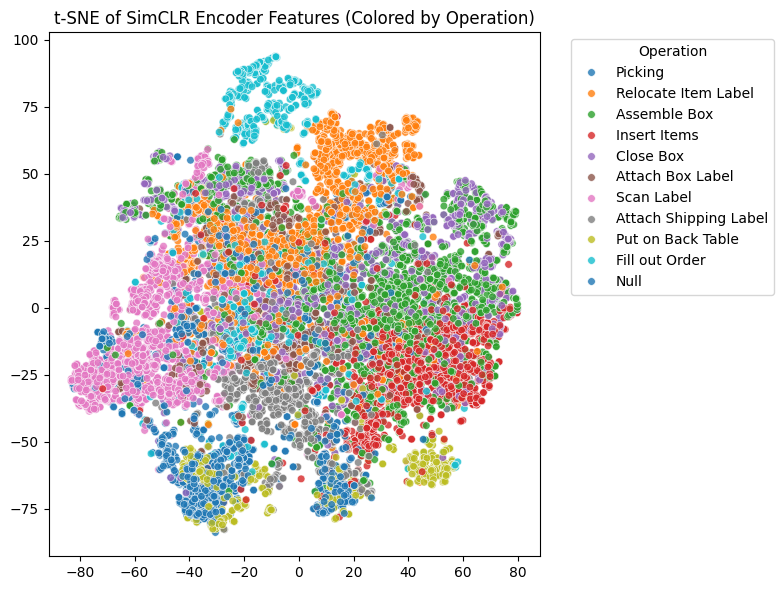

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np

# --- モデル構造を再定義 ---
model = SimCLR(
    input_dim=6,
    seq_len=256,
    hidden_dim=64,
    feature_dim=128,
    projection_dim=64,
    dropout=0.3
)

# --- 全体の重みを読み込む ---
model.load_state_dict(torch.load("./model/encoder_100.pth", map_location="cpu"))
model.eval()

encoder = model.encoder  # SimCLR の内部エンコーダ
encoder.to(device)
encoder.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder.to(device)

# --- 埋め込み計算 ---
features, labels = [], []

with torch.no_grad():
    for Xb, yb in test_loader:  # test_loader はラベル付きデータ
        Xb = Xb.to(device)
        feat = encoder(Xb)       # shape: (B, 128)
        features.append(feat.cpu().numpy())
        labels.append(yb.numpy())

features = np.concatenate(features)
labels = np.concatenate(labels)

print("Feature shape:", features.shape)

# --- t-SNE 変換 ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_emb = tsne.fit_transform(features)

# --- 可視化 ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_emb[:, 0],
    y=X_emb[:, 1],
    hue=le.inverse_transform(labels),  # ✅ 一括で処理
    palette="tab10",
    s=30,
    alpha=0.8
)

plt.title("t-SNE of SimCLR Encoder Features (Colored by Operation)")
plt.legend(bbox_to_anchor=(1.05, 1), title="Operation")
plt.tight_layout()
plt.show()


In [ ]:
# CNN モデル定義
class CNNShortWindow(nn.Module):
    def __init__(self, in_ch=6, num_classes=11):
        super().__init__()
        ks = 5
        nf = 64
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, nf, kernel_size=(ks,1), padding=(ks//2,0)),
            nn.BatchNorm2d(nf),
            nn.ReLU(),
            nn.Conv2d(nf, nf, kernel_size=(ks,1), padding=(ks//2,0)),
            nn.BatchNorm2d(nf),
            nn.ReLU(),
            nn.Conv2d(nf, nf, kernel_size=(ks,1), padding=(ks//2,0)),
            nn.BatchNorm2d(nf),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(nf, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x).squeeze(-1).squeeze(-1)
        return self.fc(x)
    

class DeepConvLstm(nn.Module):
    """論文で提案されている構成
    """
    def __init__(self, in_ch: int = 6, num_classes: int = None):
        super().__init__()
        if num_classes is None:
            num_classes = len(OPENPACK_OPERATIONS)

        # -- [1] CNN (畳み込み層) --
        # *** Edit Here ***
        num_conv_layers = 2 # 使用する畳み込み層の数 (Default: 4)
        num_conv_filter = 64 # 各層の畳み込みフィルタの数 (Default: 64)
        ks = 10 # 畳み込みフィルタのサイズ; kernel size, 
        # ******************
        
        blocks = []
        for i in range(num_conv_layers):
            in_ch_ = in_ch if i == 0 else 64
            blocks.append(
                nn.Sequential(
                    nn.Conv2d(in_ch_, 64, kernel_size=(ks, 1), padding=(2, 0), stride=(2, 1)),
                    nn.BatchNorm2d(64),
                    nn.ReLU(),
                )
            )
        self.conv_blocks = nn.ModuleList(blocks)

        # -- [2] LSTM --
        # *** Edit Here ***        
        hidden_units = 64 # LSTM層の隠れニューロンの数
        # ******************
        
        self.lstm6 = nn.LSTM(num_conv_filter, hidden_units, batch_first=True)
        self.lstm7 = nn.LSTM(hidden_units, hidden_units, batch_first=True)
        self.dropout6 = nn.Dropout(p=0.5)
        self.dropout7 = nn.Dropout(p=0.5)

        # -- [3] 出力層 --
        self.out8 = nn.Conv2d(
            hidden_units,
            num_classes,
            1,
            stride=1,
            padding=0,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): shape = (B, CH, T, 1)
        Returns:
            torch.Tensor: shape = (B, N_CLASSES, T, 1)
        """
        # -- [1] Conv --
        for block in self.conv_blocks:
            x = block(x)

        # -- [2] LSTM (!! 追加 !!) --
        # Reshape: (B, CH, 1, T) -> (B, T, CH)
        x = x.squeeze(3).transpose(1, 2)

        x, _ = self.lstm6(x)
        x = self.dropout6(x)
        x, _ = self.lstm7(x)
        x = self.dropout7(x)

        # Reshape: (B, T, CH) -> (B, CH, T, 1)
        x = x.transpose(1, 2).unsqueeze(3) 
        
        # -- [3] 出力層 --
        x = self.out8(x)
        return x



In [ ]:


# 学習設定
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNNShortWindow(in_ch=6, num_classes=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 訓練ループ
for epoch in range(10):
    model.train()
    loss_sum = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
    print(f"[Epoch {epoch+1}] Loss: {loss_sum/len(train_loader):.4f}")


# 評価
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        pred = model(Xb).argmax(dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(pred)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(le.inverse_transform(y_true), le.inverse_transform(y_pred)))

[Epoch 1] Loss: 1.5497
[Epoch 2] Loss: 0.9934
[Epoch 3] Loss: 0.8234
[Epoch 4] Loss: 0.7350
[Epoch 5] Loss: 0.6784
[Epoch 6] Loss: 0.6343
[Epoch 7] Loss: 0.6114
[Epoch 8] Loss: 0.5857
[Epoch 9] Loss: 0.5607
[Epoch 10] Loss: 0.5454
                       precision    recall  f1-score   support

         Assemble Box       0.56      0.84      0.67      1959
     Attach Box Label       0.78      0.44      0.56       537
Attach Shipping Label       0.81      0.77      0.79       844
            Close Box       0.60      0.32      0.42      1212
       Fill out Order       0.85      0.82      0.84       926
         Insert Items       0.80      0.79      0.80      1104
                 Null       0.00      0.00      0.00        21
              Picking       0.80      0.69      0.74      1261
    Put on Back Table       0.88      0.72      0.79       569
  Relocate Item Label       0.79      0.80      0.79      1788
           Scan Label       0.83      0.92      0.87      1638

           

/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kisho_ucl/kisho_ws/har_warehouse/.venv_openpack/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

In [ ]:
df_r = df_r.sort_values("unixtime")
df_l = df_l.sort_values("unixtime")

df_merged = pd.merge_asof(
    df_r, df_l,
    on="unixtime",
    suffixes=("_r", "_l"),
    tolerance=20,  # 20ミリ秒以内で近い値をマッチ
    direction="nearest"
)

print("右手:", df_r.shape, "左手:", df_l.shape, "結合後:", df_merged.shape)


右手: (59900, 12) 左手: (59900, 12) 結合後: (59900, 23)


In [ ]:
class DeepConvLstm(nn.Module):
    """論文で提案されている構成
    """
    def __init__(self, in_ch: int = 6, num_classes: int = None):
        super().__init__()
        if num_classes is None:
            num_classes = len(OPENPACK_OPERATIONS)

        # -- [1] CNN (畳み込み層) --
        # *** Edit Here ***
        num_conv_layers = 3 # 使用する畳み込み層の数 (Default: 4)
        num_conv_filter = 64 # 各層の畳み込みフィルタの数 (Default: 64)
        ks = 10 # 畳み込みフィルタのサイズ; kernel size, 
        # ******************
        
        blocks = []
        for i in range(num_conv_layers):
            in_ch_ = in_ch if i == 0 else 64
            blocks.append(
                nn.Sequential(
                    nn.Conv2d(in_ch_, 64, kernel_size=(ks, 1), padding=(2, 0), stride=(2, 1)),
                    nn.BatchNorm2d(64),
                    nn.ReLU(),
                )
            )
        self.conv_blocks = nn.ModuleList(blocks)

        # -- [2] LSTM --
        # *** Edit Here ***
        hidden_units = 128 # LSTM層の隠れニューロンの数
        # ******************
        
        self.lstm6 = nn.LSTM(num_conv_filter, hidden_units, batch_first=True)
        self.lstm7 = nn.LSTM(hidden_units, hidden_units, batch_first=True)
        self.dropout6 = nn.Dropout(p=0.5)
        self.dropout7 = nn.Dropout(p=0.5)

        # -- [3] 出力層 --
        self.out8 = nn.Conv2d(
            hidden_units,
            num_classes,
            1,
            stride=1,
            padding=0,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): shape = (B, CH, T, 1)
        Returns:
            torch.Tensor: shape = (B, N_CLASSES, T, 1)
        """
        # -- [1] Conv --
        for block in self.conv_blocks:
            x = block(x)

        # -- [2] LSTM (!! 追加 !!) --
        # Reshape: (B, CH, 1, T) -> (B, T, CH)
        x = x.squeeze(3).transpose(1, 2)

        x, _ = self.lstm6(x)
        x = self.dropout6(x)
        x, _ = self.lstm7(x)
        x = self.dropout7(x)

        # Reshape: (B, T, CH) -> (B, CH, T, 1)
        x = x.transpose(1, 2).unsqueeze(3) 
        
        # -- [3] 出力層 --
        x = self.out8(x)
        return x


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = DeepConvLstm(in_ch=6, num_classes=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 訓練ループ
for epoch in range(10):
    model.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(Xb)              # (B, num_classes, T, 1)
        out = out.mean(dim=2).squeeze(-1)  # 時系列方向平均で (B, num_classes)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: loss = {total_loss/len(train_loader):.4f}")


# 評価
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        pred = model(Xb).mean(dim=2).squeeze(-1).argmax(dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(pred)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(le.inverse_transform(y_true), le.inverse_transform(y_pred)))

Epoch 1: loss = 1.4712
Epoch 2: loss = 0.9267
Epoch 3: loss = 0.7601
Epoch 4: loss = 0.6647
Epoch 5: loss = 0.5980
Epoch 6: loss = 0.5430
Epoch 7: loss = 0.5010
Epoch 8: loss = 0.4640
Epoch 9: loss = 0.4351
Epoch 10: loss = 0.4026
                       precision    recall  f1-score   support

         Assemble Box       0.60      0.82      0.69      1959
     Attach Box Label       0.79      0.53      0.63       537
Attach Shipping Label       0.91      0.73      0.81       844
            Close Box       0.65      0.31      0.42      1212
       Fill out Order       0.86      0.82      0.84       926
         Insert Items       0.78      0.74      0.76      1104
                 Null       0.00      0.00      0.00        21
              Picking       0.73      0.80      0.77      1261
    Put on Back Table       0.94      0.68      0.79       569
  Relocate Item Label       0.70      0.87      0.77      1788
           Scan Label       0.90      0.87      0.89      1638

           

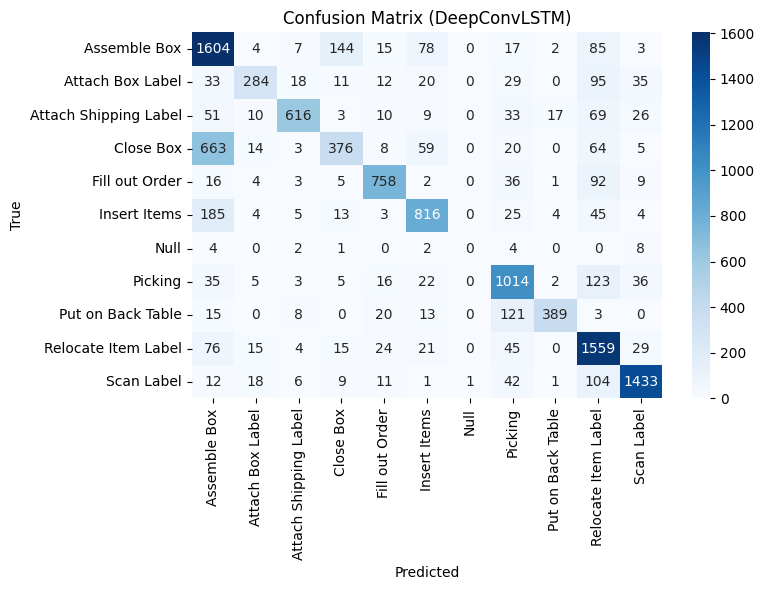

[[1604    4    7  144   15   78    0   17    2   85    3]
 [  33  284   18   11   12   20    0   29    0   95   35]
 [  51   10  616    3   10    9    0   33   17   69   26]
 [ 663   14    3  376    8   59    0   20    0   64    5]
 [  16    4    3    5  758    2    0   36    1   92    9]
 [ 185    4    5   13    3  816    0   25    4   45    4]
 [   4    0    2    1    0    2    0    4    0    0    8]
 [  35    5    3    5   16   22    0 1014    2  123   36]
 [  15    0    8    0   20   13    0  121  389    3    0]
 [  76   15    4   15   24   21    0   45    0 1559   29]
 [  12   18    6    9   11    1    1   42    1  104 1433]]


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 混同行列を作成
cm = confusion_matrix(
    le.inverse_transform(y_true),
    le.inverse_transform(y_pred),
    labels=le.classes_
)

# 可視化
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (DeepConvLSTM)")
plt.tight_layout()
plt.show()

print(cm)

In [ ]:
---

SyntaxError: invalid syntax (1947214667.py, line 1)

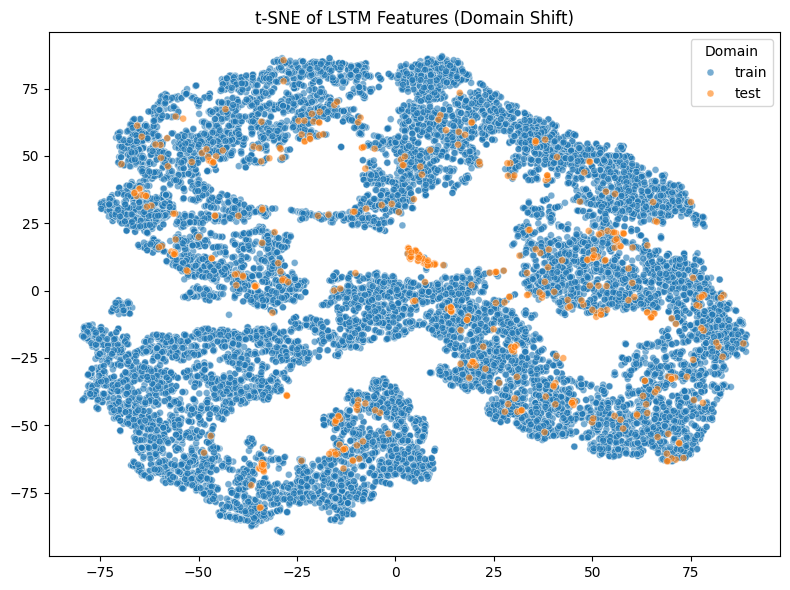

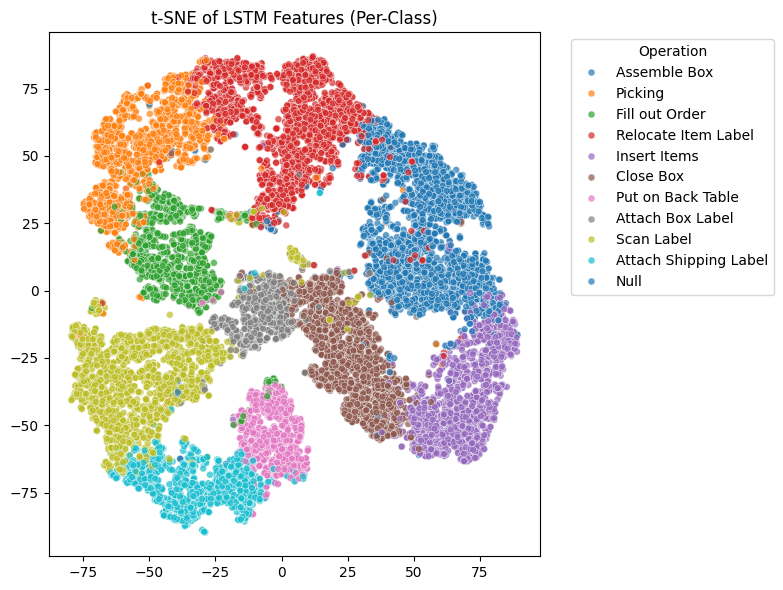

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# --------------------------------------------------------
# LSTM出力を抽出する関数
# --------------------------------------------------------
def extract_lstm_features(model, dataloader, device="cuda"):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for Xb, yb in dataloader:
            Xb = Xb.to(device)
            # [1] Conv部分
            for block in model.conv_blocks:
                Xb = block(Xb)
            # [2] LSTM入力に変換
            x = Xb.squeeze(3).transpose(1, 2)
            # [3] LSTM出力
            x, _ = model.lstm6(x)
            x = model.dropout6(x)
            x, _ = model.lstm7(x)
            x = model.dropout7(x)
            # [4] 時系列平均を1ベクトルに集約
            feat = x.mean(dim=1).cpu().numpy()  # (B, hidden_dim)
            features.append(feat)
            labels.append(yb.numpy())
    return np.concatenate(features), np.concatenate(labels)

# --------------------------------------------------------
# 特徴抽出（train/test両方）
# --------------------------------------------------------
train_feats, train_labels = extract_lstm_features(model, train_loader)
test_feats, test_labels = extract_lstm_features(model, test_loader)

# --------------------------------------------------------
# t-SNEで2次元に圧縮
# --------------------------------------------------------
X_all = np.concatenate([train_feats, test_feats])
y_all = np.concatenate([train_labels, test_labels])
domain = np.array(["train"] * len(train_feats) + ["test"] * len(test_feats))

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_emb = tsne.fit_transform(X_all)

# --------------------------------------------------------
# 可視化 (被験者ドメインで色分け)
# --------------------------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_emb[:,0], y=X_emb[:,1],
    hue=domain,
    palette={"train": "tab:blue", "test": "tab:orange"},
    alpha=0.6, s=25
)
plt.title("t-SNE of LSTM Features (Domain Shift)")
plt.legend(title="Domain")
plt.tight_layout()
plt.show()


# --------------------------------------------------------
# 可視化 (クラスラベルで色分け)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_emb[:,0], y=X_emb[:,1],
    hue=le.inverse_transform(y_all),  # ← ここを修正（まとめて渡す）
    palette="tab10",
    alpha=0.7, s=25
)
plt.title("t-SNE of LSTM Features (Per-Class)")
plt.legend(title="Operation", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()



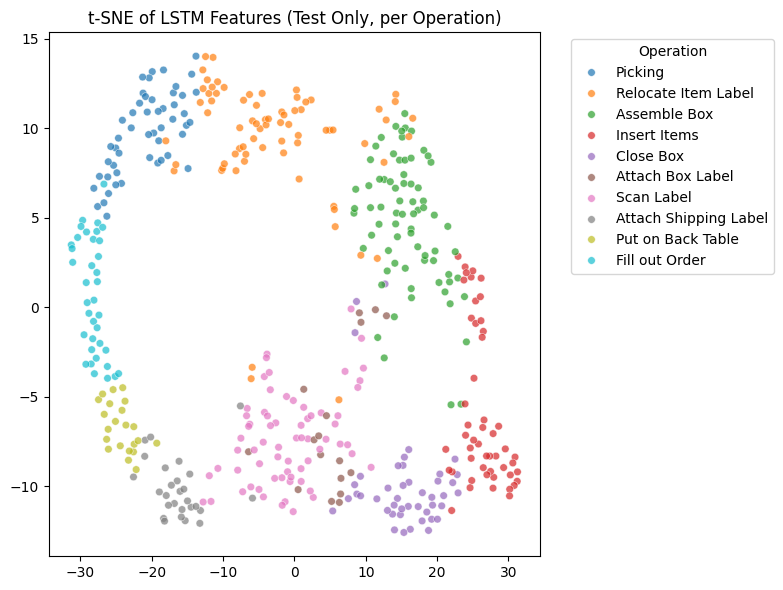

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# test特徴のみ抽出
X_emb_test = TSNE(
    n_components=2, random_state=42, perplexity=30
).fit_transform(test_feats)

# 可視化（クラスラベル）
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_emb_test[:, 0],
    y=X_emb_test[:, 1],
    hue=le.inverse_transform(test_labels),
    palette="tab10",
    alpha=0.7,
    s=30,
)
plt.title("t-SNE of LSTM Features (Test Only, per Operation)")
plt.legend(title="Operation", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()
